## **Brain Tumor Detection Using Deep Learning (CNN)**

### **Introduction**

This project aims to build a Deep Learning model to detect brain tumors from MRI images using Convolutional Neural Networks (CNN).

Medical image classification is an important application of computer vision.
This model classifies images into two categories: **Healthy and Tumor.**

### **Objective**

Objective of this project is:

1. To build a CNN model for image classification
2. To classify MRI images into Healthy and Tumor
3. To evaluate model accuracy
4. To test model on new images
5. To save trained model for future use

Required libraries are imported

In [ ]:
pip install tensorflow

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
from matplotlib.pyplot import imshow
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [9]:
data = (r"C:\Users\HP\Downloads\prjct")

In [10]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [12]:
train_data = datagen.flow_from_directory(
    data,
    target_size=(128,128),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

Found 7695 images belonging to 2 classes.


In [14]:
valid_data = datagen.flow_from_directory(
    data,
    target_size=(128,128),
    batch_size=32,
    class_mode="binary",
    subset="validation"
)

Found 1923 images belonging to 2 classes.


In [15]:
print(train_data.class_indices)

{'Healthy': 0, 'Tumor': 1}


In [16]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation="relu", input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation="relu"))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation="relu"))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(1, activation="sigmoid"))

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.compile(
    optimizer=Adam(),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [18]:
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=10
)

Epoch 1/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 73s 297ms/step - accuracy: 0.8113 - loss: 0.4195 - val_accuracy: 0.9085 - val_loss: 0.3555
Epoch 2/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 58s 239ms/step - accuracy: 0.9183 - loss: 0.2134 - val_accuracy: 0.9288 - val_loss: 0.3071
Epoch 3/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 58s 243ms/step - accuracy: 0.9458 - loss: 0.1389 - val_accuracy: 0.9319 - val_loss: 0.3907
Epoch 4/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 64s 264ms/step - accuracy: 0.9617 - loss: 0.0991 - val_accuracy: 0.9319 - val_loss: 0.4237
Epoch 5/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 64s 267ms/step - accuracy: 0.9739 - loss: 0.0691 - val_accuracy: 0.9314 - val_loss: 0.4182
Epoch 6/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 68s 282ms/step - accuracy: 0.9799 - loss: 0.0504 - val_accuracy: 0.9298 - val_loss: 0.4865
Epoch 7/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 72s 297ms/step - accuracy: 0.9819 - loss: 0.0474 - val_accuracy: 0.9220 - val_loss: 0.3399
Epoch 8/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 82s 342ms/step - accuracy: 0.9819 - loss: 0

In [38]:
loss, acc = model.evaluate(valid_data)

print("Validation Accuracy:", acc)

61/61 ━━━━━━━━━━━━━━━━━━━━ 9s 141ms/step - accuracy: 0.9423 - loss: 0.5632
Validation Accuracy: 0.9422776699066162


### **Accuracy & Loss Graph**

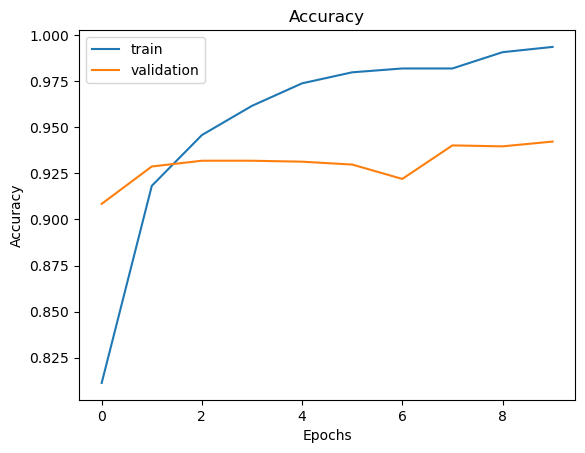

In [21]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Accuracy")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(["train","validation"])
plt.show()

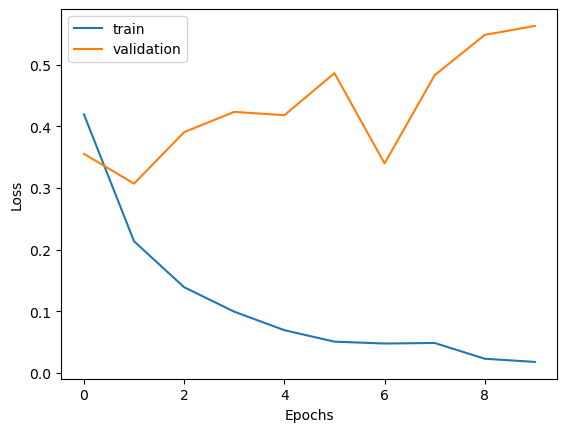

In [22]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(["train","validation"])
plt.show()

In [23]:
model.save("brain_tumor_model.h5")

### **Prediction on New Image**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted Class: Healthy


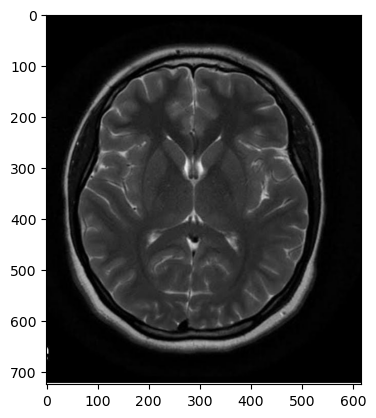

In [36]:
names = ["Healthy", "Tumor"]
img = Image.open(r"C:\Users\HP\Downloads\WhatsApp Image 2026-03-23 at 7.08.36 PM.jpeg")
img_resized = img.resize((128,128))
x = np.array(img_resized)
x = x / 255.0
x = x.reshape(1,128,128,3)
pred = model.predict(x)

if pred[0][0] > 0.5:
    classification = 1
else:
    classification = 0

imshow(img)
print(f"Predicted Class: {names[classification]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predicted Class: Tumor


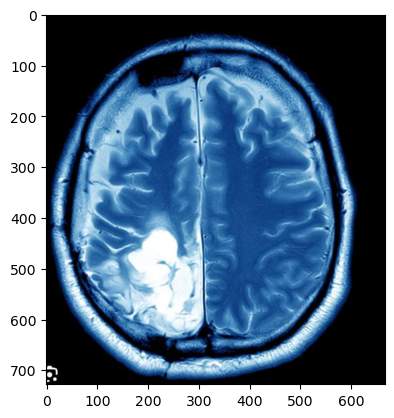

In [37]:
img = Image.open(r"C:\Users\HP\Downloads\WhatsApp Image 2026-03-23 at 7.16.17 PM.jpeg")
img_resized = img.resize((128,128))
x = np.array(img_resized)
x = x / 255.0
x = x.reshape(1,128,128,3)
pred = model.predict(x)

if pred[0][0] > 0.5:
    classification = 1
else:
    classification = 0

imshow(img)
print(f"Predicted Class: {names[classification]}")

## **Conclusion**

A Convolutional Neural Network (CNN) was developed to classify brain MRI images into Healthy and Tumor.

The dataset was preprocessed using ImageDataGenerator and the model was trained using deep learning techniques. The performance of the model was evaluated using validation data.

The model achieved about 94% validation accuracy and successfully predicted new unseen images. This shows that deep learning can be used effectively for medical image classification tasks.

The trained model was saved and can be reused for future prediction.